# TRABAJO PRÁCTICO N° 4: ANÁLISIS PREDICTIVO INTEGRAL
**Asignatura:** Análisis de Datos Empresariales - Unidad 6  
**Carrera:** Ingeniería en Sistemas de Información  
**Facultad:** UTN - Facultad Regional Resistencia  
**Grupo N°:** 6  
**Metodología Utilizada:** CRISP-DM (Cross Industry Standard Process for Data Mining)  

---

## FASE 3: PREPARACIÓN DE LOS DATOS (DATA PREPARATION)
En esta fase, transformamos las tablas relacionales del Data Warehouse (Esquema de Estrella) en un **Dataset Maestro unificado**. Cada fila representará un estudiante único y las columnas consolidarán sus métricas académicas y demográficas clave (grano: alumno).

In [40]:
import pandas as pd

In [41]:
df_estudiante = pd.read_csv('data/dim_estudiante.tsv', sep="\t", encoding="latin1")
df_inscripcion = pd.read_csv('data/fact_inscripcion.tsv', sep="\t", encoding="latin1")
df_estudiante.head()
df_inscripcion.head()

,inscripcion_skey,estudiante_skey,tiempo_skey,dictado_skey,estado,abandono
0,1,117876,20230213,1,Activa,0
1,2,117876,20230203,2,Baja,1
2,3,117876,20240209,4,Activa,0
3,4,117876,20230323,5,Activa,0
4,5,117876,20240321,8,Activa,0


In [42]:
df_inscripciones_por_alumno = (
    inscripciones.groupby("estudiante_skey")
    .agg(total_inscripciones=("inscripcion_skey", "count"))
    .reset_index()
)
df_inscripciones_por_alumno.head()

,estudiante_skey,total_inscripciones
0,1,10
1,2,6
2,3,6
3,4,7
4,5,10


In [43]:
df_fusion = pd.merge(
    df_estudiante, df_inscripciones_por_alumno, on="estudiante_skey", how="left"
)
df_fusion.head()

,estudiante_skey,id_estudiante,dni,nombre,apellido,genero,fecha_nacimiento,nacionalidad,anio_ingreso,edad_ingreso,...,anio_abandono,nombre_programa,tipo_programa,duracion_programa,anio_plan_programa,facultad_programa,valid_from,valid_to,es_actual,total_inscripciones
0,1,45414,20000016,Gonzalo,Muñoz,M,2001-05-20,Venezolana,2023,22,...,NaN,Ingeniería Industrial,Grado,5,NaN,Facultad Regional Córdoba,2026-05-26,NaN,1,10.0
1,2,106375,20000125,Soledad,Suárez,F,2001-12-24,Argentina,2023,22,...,NaN,Ingeniería En Sistemas De Información,Grado,5,NaN,Facultad Regional Mendoza,2026-05-26,NaN,1,6.0
2,3,125211,20000181,Matías,García,M,2005-08-05,Argentina,2021,16,...,NaN,Ingeniería Industrial,Grado,5,NaN,Facultad Regional Córdoba,2026-05-26,NaN,1,6.0
3,4,28539,20000646,Maximiliano,Álvarez,M,2003-03-20,Argentina,2023,20,...,NaN,Ingeniería Mecánica,Grado,5,NaN,Facultad Regional Buenos Aires,2026-05-26,NaN,1,7.0
4,5,78953,20000756,Claudio,Sánchez,M,2007-04-02,Argentina,2020,13,...,NaN,Ingeniería En Sistemas De Información,Grado,5,NaN,Facultad Regional Rosario,2026-05-26,NaN,1,10.0


In [44]:
columna_hecho = (
    "total_inscripciones"  
)

df_fusion["es_ingresante_sin_cursada"] = (
    df_fusion[columna_hecho].isna().astype(int)
)
df_fusion.head()

,estudiante_skey,id_estudiante,dni,nombre,apellido,genero,fecha_nacimiento,nacionalidad,anio_ingreso,edad_ingreso,...,nombre_programa,tipo_programa,duracion_programa,anio_plan_programa,facultad_programa,valid_from,valid_to,es_actual,total_inscripciones,es_ingresante_sin_cursada
0,1,45414,20000016,Gonzalo,Muñoz,M,2001-05-20,Venezolana,2023,22,...,Ingeniería Industrial,Grado,5,NaN,Facultad Regional Córdoba,2026-05-26,NaN,1,10.0,0
1,2,106375,20000125,Soledad,Suárez,F,2001-12-24,Argentina,2023,22,...,Ingeniería En Sistemas De Información,Grado,5,NaN,Facultad Regional Mendoza,2026-05-26,NaN,1,6.0,0
2,3,125211,20000181,Matías,García,M,2005-08-05,Argentina,2021,16,...,Ingeniería Industrial,Grado,5,NaN,Facultad Regional Córdoba,2026-05-26,NaN,1,6.0,0
3,4,28539,20000646,Maximiliano,Álvarez,M,2003-03-20,Argentina,2023,20,...,Ingeniería Mecánica,Grado,5,NaN,Facultad Regional Buenos Aires,2026-05-26,NaN,1,7.0,0
4,5,78953,20000756,Claudio,Sánchez,M,2007-04-02,Argentina,2020,13,...,Ingeniería En Sistemas De Información,Grado,5,NaN,Facultad Regional Rosario,2026-05-26,NaN,1,10.0,0


In [45]:
# Separamos los datasets como acordamos para la estrategia del proyecto
# Grupo A: Los 3.473 alumnos que se inscribieron a la carrera pero nunca registraron cursada inicial
df_riesgo_temprano = df_fusion[df_fusion["es_ingresante_sin_cursada"] == 1]

# Grupo B: Los alumnos que sí registraron cursada (con los que vas a entrenar el modelo de ML)
df_modelo = df_fusion[df_fusion["es_ingresante_sin_cursada"] == 0]

df_riesgo_temprano.head()

,estudiante_skey,id_estudiante,dni,nombre,apellido,genero,fecha_nacimiento,nacionalidad,anio_ingreso,edad_ingreso,...,nombre_programa,tipo_programa,duracion_programa,anio_plan_programa,facultad_programa,valid_from,valid_to,es_actual,total_inscripciones,es_ingresante_sin_cursada
24,25,114512,20006443,Rodrigo,Benítez,M,2004-12-16,Boliviana,2020,16,...,Ingeniería Química,Grado,5,NaN,Facultad Regional Buenos Aires,2026-05-26,NaN,1,NaN,1
130,131,14758,20030151,Sebastián,Ramos,M,1998-07-15,Argentina,2024,26,...,Tecnicatura Universitaria En Programación,Pregrado,3,NaN,Facultad Regional Buenos Aires,2026-05-26,NaN,1,NaN,1
148,149,89672,20033117,Iván,Romero,M,2007-08-22,Argentina,2020,13,...,Ingeniería Mecánica,Grado,5,NaN,Facultad Regional Buenos Aires,2026-05-26,NaN,1,NaN,1
203,204,76879,20043295,Valeria,Cabrera,F,2003-01-21,Argentina,2024,21,...,Tecnicatura Universitaria En Programación,Pregrado,3,NaN,Facultad Regional Buenos Aires,2026-05-26,NaN,1,NaN,1
235,236,96370,20047833,Julián,Souza,M,2005-09-11,Venezolana,2020,15,...,Ingeniería Aeronáutica,Grado,5,NaN,Facultad Regional Buenos Aires,2026-05-26,NaN,1,NaN,1


In [46]:
# Guardamos el reporte del Grupo A para la acción institucional que planteaste en el Paso 1
df_riesgo_temprano.to_csv("data/alumnos_riesgo_temprano.csv", index=False)

# Verificamos los tamaños en el notebook 
print(f"Total de estudiantes en el DW: {len(df_estudiante)}")
print(
    f"Alumnos en riesgo temprano: {len(df_riesgo_temprano)}"
)
print(f"Alumnos listos para el modelo analítico: {len(df_modelo)}")

Total de estudiantes en el DW: 127433
Alumnos en riesgo temprano: 3044
Alumnos listos para el modelo analítico: 124389


In [47]:
# Cargar las dimensiones
df_dictado = pd.read_csv("data/dim_dictado.tsv", sep='\t', encoding='latin1')
df_examen = pd.read_csv("data/fact_examen_estudiante.tsv", sep='\t', encoding='latin1')

# Filtrar los id_dictado que corresponden a Algoritmos
# Usamos .str.contains por si varía un poco el texto (mayúsculas/minúsculas)
df_algoritmos = df_dictado[
    df_dictado["nombre_curso"].str.contains(
        "Algoritmos", case=False, na=False
    )
]
# Creamos una lista con todos los ID únicos de dictado para esa materia
ids_dictados_algoritmos = df_algoritmos["id_dictado"].unique().tolist()
print(
    f"Los IDs de dictado que corresponden a Algoritmos son: {ids_dictados_algoritmos}"
)
df_algoritmos.columns.tolist()
#df_examen.head()

Los IDs de dictado que corresponden a Algoritmos son: [193, 194, 195, 196, 413, 414, 415, 416, 590, 591, 592, 593, 863, 864, 865, 866, 1035, 1036, 1037, 1038, 1241, 1242, 1243, 1244, 1445, 1446, 1447, 1448, 1666, 1667, 1668, 1669, 1868, 1869, 1870, 1871, 2036, 2037, 2038, 2039, 2083, 2084, 2085, 2086, 2129, 2130, 2131, 2132, 2198, 2199, 2200, 2201]


['dictado_skey',
 'id_dictado',
 'periodo',
 'turno',
 'aula',
 'cupo_maximo',
 'codigo_curso',
 'nombre_curso',
 'horas_teorica',
 'horas_ejercicio',
 'horas_laboratorio',
 'nivel_curso',
 'nombre_docente',
 'apellido_docente',
 'titulo_docente',
 'categoria_docente',
 'dedicacion_docente',
 'nombre_departamento',
 'nombre_facultad',
 'ciudad_facultad',
 'provincia_facultad',
 'valid_from',
 'valid_to',
 'es_actual']

In [48]:
# Evaluamos si el id_dictado del examen está dentro de nuestra lista de Algoritmos
df_examen["es_reprobada"] = 1 - df_examen["aprobado"]

df_examen["es_algoritmos_reprobada"] = (
    df_examen["dictado_skey"].isin(ids_dictados_algoritmos)
    & (df_examen["aprobado"] == 0)
).astype(int)
df_examen.head()

,examen_estudiante_skey,estudiante_skey,tiempo_skey,dictado_skey,nota,numero_intentos,aprobado,es_reprobada,es_algoritmos_reprobada
0,1,64620,20230701,270,6.3,1,1,0,0
1,2,84438,20230701,1245,3.1,1,0,1,0
2,3,68254,20230701,867,2.9,1,0,1,0
3,4,117876,20230701,1,3.9,1,0,1,0
4,5,96916,20230701,9,2.9,1,0,1,0


In [49]:
# AGRUPAMOS a nivel estudiante
df_academicos = (
    df_examen.groupby("estudiante_skey")
    .agg(
        promedio_notas=("nota", "mean"),
        materias_reprobadas=("es_reprobada", "sum"),
        reprobo_algoritmos=("es_algoritmos_reprobada", "max"),
    )
    .reset_index()
)

df_academicos.head()

,estudiante_skey,promedio_notas,materias_reprobadas,reprobo_algoritmos
0,1,3.500000,6,0
1,2,3.675000,3,1
2,3,5.300000,0,0
3,4,3.890000,7,0
4,5,5.157143,2,0


In [51]:
# Hacemos un merge intermedio: le traemos a las inscripciones el nivel_curso desde la dimensión dictado
# Unimos por 'id_dictado' (reemplazalo por el nombre exacto de la clave si varía)
df_inscripcion_con_nivel = pd.merge(
    df_inscripcion,
    df_dictado[["dictado_skey", "nivel_curso"]],
    on="dictado_skey",
    how="left"
)

# Ahora sí, agrupamos por estudiante usando la tabla que ya tiene el nivel embebido
df_nivel = (
    df_inscripcion_con_nivel.groupby("estudiante_skey")
    .agg(nivel_curso_maximo=("nivel_curso", "max"))
    .reset_index()
)
df_nivel.head()

,estudiante_skey,nivel_curso_maximo
0,1,2
1,2,2
2,3,4
3,4,2
4,5,5


In [71]:
# Pegamos todo a la dimensión estudiante (df_modelo que filtramos en el paso 1)
df_master = pd.merge(df_modelo, df_academicos, on='estudiante_skey', how='left')
df_master = pd.merge(df_master, df_nivel, on='estudiante_skey', how='left')

# Rellenamos nulos por si las dudas (Garbage In, Garbage Out) [cite: 716]
df_master['promedio_notas'] = df_master['promedio_notas'].fillna(0)
df_master['materias_reprobadas'] = df_master['materias_reprobadas'].fillna(0)
df_master['reprobo_algoritmos'] = df_master['reprobo_algoritmos'].fillna(0)
df_master['nivel_curso_maximo'] = df_master['nivel_curso_maximo'].fillna(1) # Si no tiene nivel, asumimos ingresante

df_master.to_csv("data/master.csv", index=False)

print(df_master.columns.tolist())
df_master.head()

['estudiante_skey', 'id_estudiante', 'dni', 'nombre', 'apellido', 'genero', 'fecha_nacimiento', 'nacionalidad', 'anio_ingreso', 'edad_ingreso', 'egreso_carrera', 'anio_egreso', 'abandono_carrera', 'anio_abandono', 'nombre_programa', 'tipo_programa', 'duracion_programa', 'anio_plan_programa', 'facultad_programa', 'valid_from', 'valid_to', 'es_actual', 'total_inscripciones', 'es_ingresante_sin_cursada', 'promedio_notas', 'materias_reprobadas', 'reprobo_algoritmos', 'nivel_curso_maximo']


,estudiante_skey,id_estudiante,dni,nombre,apellido,genero,fecha_nacimiento,nacionalidad,anio_ingreso,edad_ingreso,...,facultad_programa,valid_from,valid_to,es_actual,total_inscripciones,es_ingresante_sin_cursada,promedio_notas,materias_reprobadas,reprobo_algoritmos,nivel_curso_maximo
0,1,45414,20000016,Gonzalo,Muñoz,M,2001-05-20,Venezolana,2023,22,...,Facultad Regional Córdoba,2026-05-26,NaN,1,10.0,0,3.500000,6.0,0.0,2
1,2,106375,20000125,Soledad,Suárez,F,2001-12-24,Argentina,2023,22,...,Facultad Regional Mendoza,2026-05-26,NaN,1,6.0,0,3.675000,3.0,1.0,2
2,3,125211,20000181,Matías,García,M,2005-08-05,Argentina,2021,16,...,Facultad Regional Córdoba,2026-05-26,NaN,1,6.0,0,5.300000,0.0,0.0,4
3,4,28539,20000646,Maximiliano,Álvarez,M,2003-03-20,Argentina,2023,20,...,Facultad Regional Buenos Aires,2026-05-26,NaN,1,7.0,0,3.890000,7.0,0.0,2
4,5,78953,20000756,Claudio,Sánchez,M,2007-04-02,Argentina,2020,13,...,Facultad Regional Rosario,2026-05-26,NaN,1,10.0,0,5.157143,2.0,0.0,5


### 3.1 Binarización e Ingeniería de Características (Train/Test Split)
Para que los algoritmos matemáticos puedan procesar la información, aplicamos **One-Hot Encoding** a las variables categóricas (como género, regional y turno). 

Luego, realizamos una partición de tipo **Hold-Out (80% Entrenamiento / 20% Testeo)**. Al existir un fuerte desbalance de clases (pocos alumnos desertores frente a la mayoría regular), configuramos el parámetro de **estratificación (`stratify=y`)** y fijamos la semilla de reproducibilidad (`random_state=42`) para garantizar que la proporción del target se mantenga idéntica en ambos sets.

In [55]:
from sklearn.model_selection import train_test_split

# 1. SELECCIÓN DE METADATA Y VARIABLES PREDICTIVAS (X)
# Dejamos fuera IDs, nombres, datos personales y variables que filtran el futuro
columnas_predictoras = [
    'genero', 
    'edad_ingreso', 
    'nombre_programa',      # Es tu dimensión Carrera (ej: Sistemas, Industrial)
    'facultad_programa',    # Es tu dimensión Regional (ej: Haedo, Buenos Aires)
    'total_inscripciones', 
    'promedio_notas', 
    'materias_reprobadas', 
    'reprobo_algoritmos', 
    'nivel_curso_maximo'
]

X_crudo = df_master[columnas_predictoras]

# 2. TRANSFORMACIÓN DE VARIABLES CATEGÓRICAS A NÚMEROS (One-Hot Encoding)
# Esto binariza 'genero', 'nombre_programa' y 'facultad_programa' automáticamente en columnas 0/1
X = pd.get_dummies(X_crudo, columns=['genero', 'nombre_programa', 'facultad_programa'], drop_first=True)

# 3. DEFINICIÓN DEL TARGET (Y)
# Convertimos tu columna booleana True/False a enteros 1/0
y = df_master['abandono_carrera'].astype(int)

# 4. PARTICIÓN DEL DATASET (Split 80% Entrenamiento / 20% Testeo)
# Fijamos una semilla (random_state=42) para que el experimento sea reproducible
# Usamos stratify=y para mantener la misma proporción de desertores en ambos lados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 5. VERIFICACIÓN DE CONTROL ACADÉMICO
print(f"Dimensiones de X_train (Entrenamiento): {X_train.shape}")
print(f"Dimensiones de X_test (Testeo): {X_test.shape}")
print("\nDistribución del Target en Entrenamiento (y_train):")
print(y_train.value_counts(normalize=True))
print("\nDistribución del Target en Testeo (y_test):")
print(y_test.value_counts(normalize=True))

Dimensiones de X_train (Entrenamiento): (99511, 23)
Dimensiones de X_test (Testeo): (24878, 23)

Distribución del Target en Entrenamiento (y_train):
abandono_carrera
0    0.937615
1    0.062385
Name: proportion, dtype: float64

Distribución del Target en Testeo (y_test):
abandono_carrera
0    0.937616
1    0.062384
Name: proportion, dtype: float64


---

## FASE 4: MODELADO Y EVALUACIÓN ANALÍTICA (MODELING)

### Algoritmo 1: Regresión Logística (Baseline Lineal)
Establecemos nuestro primer modelo de clasificación lineal. Este algoritmo estimará la probabilidad de pertenencia a la clase de riesgo basándose en una función sigmoidea. Es ideal como punto de partida para evaluar la separación lineal de nuestras variables.

In [56]:
# 1. Importamos el algoritmo de Regresión Logística
from sklearn.linear_model import LogisticRegression

# 2. Instanciamos el modelo
# Usamos class_weight='balanced' porque tu tasa de deserción es baja (~8.48%). 
# Esto le da más peso a los alumnos que abandonan para que el algoritmo aprenda mejor el patrón.
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 3. Entrenamos el modelo con los datos del set de entrenamiento (80%)
modelo_lr.fit(X_train, y_train)

print("¡Modelo de Regresión Logística entrenado con éxito!")

¡Modelo de Regresión Logística entrenado con éxito!


In [57]:
# 1. Importamos las herramientas de evaluación de Scikit-Learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 2. Generamos las predicciones sobre el set de testeo (20%)
y_pred_lr = modelo_lr.predict(X_test)

# 3. Calculamos las métricas técnicas individuales
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# 4. Mostramos el reporte unificado en pantalla
print("=== MÉTRICAS DE EVALUACIÓN: REGRESIÓN LOGÍSTICA ===")
print(f"Accuracy (Exactitud Global): {accuracy_lr:.4f}")
print(f"Precision (Precisión):        {precision_lr:.4f}")
print(f"Recall (Sensibilidad):       {recall_lr:.4f}")
print(f"F1-Score:                    {f1_lr:.4f}\n")

# Reporte detallado por clase (0: Regular, 1: Abandono)
print(classification_report(y_test, y_pred_lr, target_names=['Regular', 'Abandono']))

=== MÉTRICAS DE EVALUACIÓN: REGRESIÓN LOGÍSTICA ===
Accuracy (Exactitud Global): 0.8941
Precision (Precisión):        0.3617
Recall (Sensibilidad):       0.9124
F1-Score:                    0.5180

              precision    recall  f1-score   support

     Regular       0.99      0.89      0.94     23326
    Abandono       0.36      0.91      0.52      1552

    accuracy                           0.89     24878
   macro avg       0.68      0.90      0.73     24878
weighted avg       0.95      0.89      0.91     24878



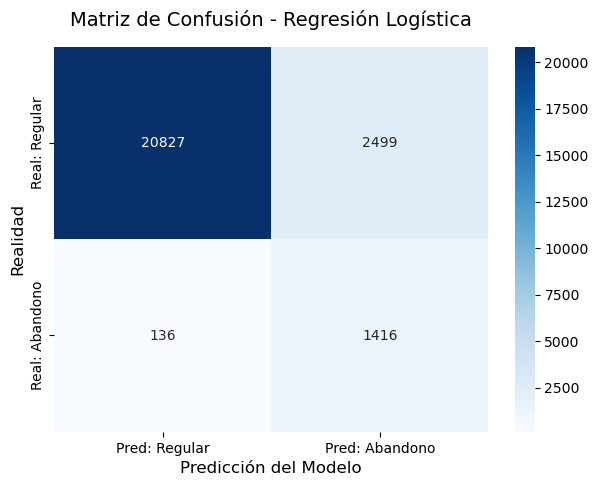

-> Verdaderos Positivos (Alumnos en riesgo detectados con éxito): 1416
-> Falsos Negativos (Alumnos en riesgo que el modelo no vio):       136
-> Falsos Positivos (Alumnos regulares etiquetados en riesgo):     2499


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculamos la matriz de confusión analítica
cm_lr = confusion_matrix(y_test, y_pred_lr)

# 2. Graficamos la matriz de forma interactiva y visual
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Regular', 'Pred: Abandono'], 
            yticklabels=['Real: Regular', 'Real: Abandono'])

plt.title('Matriz de Confusión - Regresión Logística', fontsize=14, pad=15)
plt.ylabel('Realidad', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.show()

# Interpretación técnica para el informe:
print(f"-> Verdaderos Positivos (Alumnos en riesgo detectados con éxito): {cm_lr[1,1]}")
print(f"-> Falsos Negativos (Alumnos en riesgo que el modelo no vio):       {cm_lr[1,0]}")
print(f"-> Falsos Positivos (Alumnos regulares etiquetados en riesgo):     {cm_lr[0,1]}")

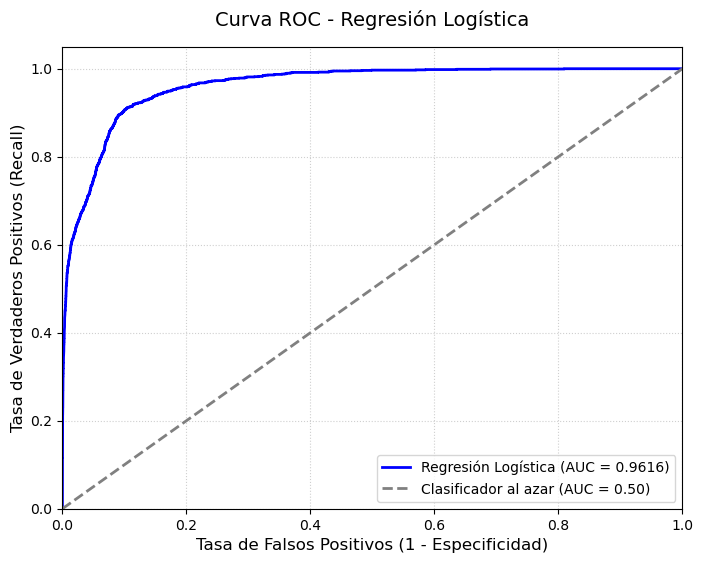

Área Bajo la Curva (AUC): 0.9616


In [59]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Obtenemos las probabilidades de predicción para la clase 1 (Abandono)
# A diferencia de .predict(), .predict_proba() nos da el 'score' exacto de probabilidad (0.0 a 1.0)
y_probs_lr = modelo_lr.predict_proba(X_test)[:, 1]

# 2. Calculamos los componentes de la curva ROC
fpr_lr, tpr_lr, umbrales_lr = roc_curve(y_test, y_probs_lr)

# 3. Calculamos la métrica AUC global
auc_lr = roc_auc_score(y_test, y_probs_lr)

# 4. Graficamos la curva ROC individual
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Regresión Logística (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Clasificador al azar (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
plt.title('Curva ROC - Regresión Logística', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Área Bajo la Curva (AUC): {auc_lr:.4f}")

### Algoritmo 2: Árbol de Decisión (Caja Blanca Alta Interpretabilidad)
Entrenamos un clasificador basado en reglas lógicas binarias. Limitamos la profundidad máxima a `max_depth=5` para evitar el sobreajuste (*overfitting*) y garantizar que el modelo sea **altamente interpretable** para los directivos de la Secretaría Académica, exponiendo de forma textual las reglas del negocio.

In [60]:
# 1. Importamos el algoritmo de Árbol de Decisión
from sklearn.tree import DecisionTreeClassifier

# 2. Instanciamos el modelo
# Usamos max_depth=5 para mantenerlo interpretable y evitar el sobreajuste (overfitting).
# Usamos class_weight='balanced' para compensar que hay menos filas de abandono.
modelo_tree = DecisionTreeClassifier(
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)

# 3. Entrenamos el modelo con nuestro set del 80%
modelo_tree.fit(X_train, y_train)

print("¡Modelo de Árbol de Decisión entrenado con éxito!")

¡Modelo de Árbol de Decisión entrenado con éxito!


In [61]:
# 1. Generamos las predicciones en base a los datos que el modelo jamás vio
y_pred_tree = modelo_tree.predict(X_test)

# 2. Calculamos las métricas analíticas
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

# 3. Imprimimos el reporte técnico en pantalla
print("=== MÉTRICAS DE EVALUACIÓN: ÁRBOL DE DECISIÓN ===")
print(f"Accuracy (Exactitud Global): {accuracy_tree:.4f}")
print(f"Precision (Precisión):        {precision_tree:.4f}")
print(f"Recall (Sensibilidad):       {recall_tree:.4f}")
print(f"F1-Score:                    {f1_tree:.4f}\n")

print(classification_report(y_test, y_pred_tree, target_names=['Regular', 'Abandono']))

=== MÉTRICAS DE EVALUACIÓN: ÁRBOL DE DECISIÓN ===
Accuracy (Exactitud Global): 0.8569
Precision (Precisión):        0.2988
Recall (Sensibilidad):       0.9601
F1-Score:                    0.4557

              precision    recall  f1-score   support

     Regular       1.00      0.85      0.92     23326
    Abandono       0.30      0.96      0.46      1552

    accuracy                           0.86     24878
   macro avg       0.65      0.91      0.69     24878
weighted avg       0.95      0.86      0.89     24878



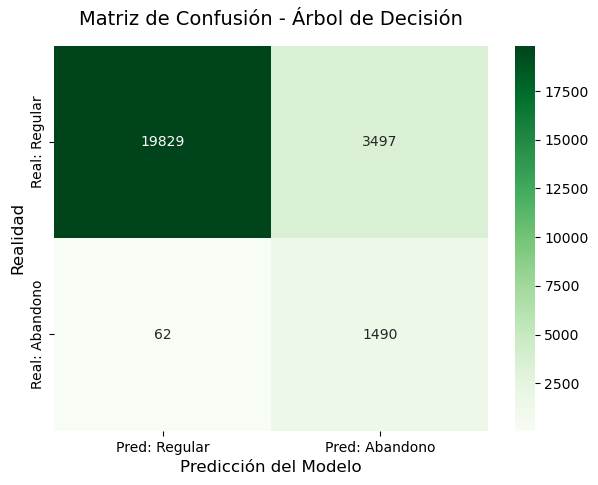

-> Verdaderos Positivos (Alumnos en riesgo detectados): 1490
-> Falsos Negativos (Alumnos en riesgo no detectados):   62
-> Falsos Positivos (Alumnos regulares marcados en riesgo): 3497


In [62]:
# 1. Calculamos la matriz de confusión para el árbol
cm_tree = confusion_matrix(y_test, y_pred_tree)

# 2. La graficamos visualmente
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred: Regular', 'Pred: Abandono'], 
            yticklabels=['Real: Regular', 'Real: Abandono'])

plt.title('Matriz de Confusión - Árbol de Decisión', fontsize=14, pad=15)
plt.ylabel('Realidad', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.show()

print(f"-> Verdaderos Positivos (Alumnos en riesgo detectados): {cm_tree[1,1]}")
print(f"-> Falsos Negativos (Alumnos en riesgo no detectados):   {cm_tree[1,0]}")
print(f"-> Falsos Positivos (Alumnos regulares marcados en riesgo): {cm_tree[0,1]}")

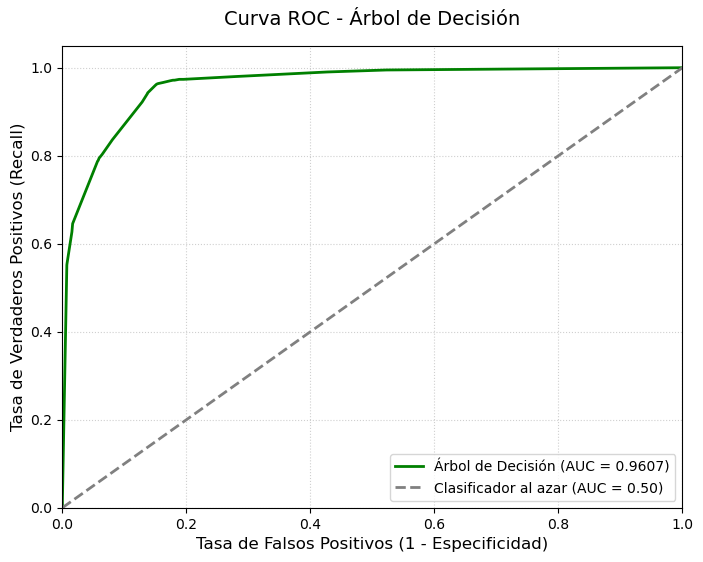

Área Bajo la Curva (AUC): 0.9607


In [63]:
# 1. Obtenemos las probabilidades de la predicción de la clase 1 (Abandono)
y_probs_tree = modelo_tree.predict_proba(X_test)[:, 1]

# 2. Calculamos los componentes ROC
fpr_tree, tpr_tree, umbrales_tree = roc_curve(y_test, y_probs_tree)
auc_tree = roc_auc_score(y_test, y_probs_tree)

# 3. Graficamos la curva ROC individual
plt.figure(figsize=(8, 6))
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'Árbol de Decisión (AUC = {auc_tree:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Clasificador al azar (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
plt.title('Curva ROC - Árbol de Decisión', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Área Bajo la Curva (AUC): {auc_tree:.4f}")

In [64]:
from sklearn.tree import export_text

# Exportamos la estructura lógica del árbol
reglas_del_arbol = export_text(modelo_tree, feature_names=list(X.columns))

# Mostramos las primeras ramas de decisión
print("=== REGLAS LÓGICAS DETECTADAS POR EL ÁRBOL ===")
print("\n".join(reglas_del_arbol.split("\n")[:30]))  # Mostramos las primeras 30 líneas para no saturar

=== REGLAS LÓGICAS DETECTADAS POR EL ÁRBOL ===
|--- total_inscripciones <= 6.50
|   |--- total_inscripciones <= 3.50
|   |   |--- nivel_curso_maximo <= 1.50
|   |   |   |--- promedio_notas <= 1.55
|   |   |   |   |--- genero_M <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- genero_M >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- promedio_notas >  1.55
|   |   |   |   |--- materias_reprobadas <= 3.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- materias_reprobadas >  3.50
|   |   |   |   |   |--- class: 0
|   |   |--- nivel_curso_maximo >  1.50
|   |   |   |--- facultad_programa_Facultad Regional Haedo <= 0.50
|   |   |   |   |--- nombre_programa_Tecnicatura Universitaria En Programación <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- nombre_programa_Tecnicatura Universitaria En Programación >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- facultad_programa_Facultad Regional Haedo >  0.50
|   |   |   |   |--- nivel_curso_maxi

### Algoritmo 3: Random Forest (Ensamble de Bosques Aleatorios)
Para resolver la inestabilidad del árbol simple, implementamos un ensamble de **100 árboles de decisión independientes (`n_estimators=100`)** entrenados con subconjuntos aleatorios. Configurando `class_weight='balanced'`, forzamos al modelo a penalizar severamente la omisión de un alumno desertor, priorizando la sensibilidad del negocio.

In [65]:
# 1. Importamos el algoritmo de Random Forest
from sklearn.ensemble import RandomForestClassifier

# 2. Instanciamos el modelo
# Usamos n_estimators=100 (un bosque con 100 árboles independientes trabajando juntos)
# Usamos class_weight='balanced' para compensar la minoría de alumnos desertores
modelo_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=6,             # Límite de profundidad para controlar el procesamiento
    class_weight='balanced', 
    random_state=42
)

# 3. Entrenamos el modelo con nuestro set del 80%
modelo_rf.fit(X_train, y_train)

print("¡Modelo de Random Forest entrenado con éxito!")

¡Modelo de Random Forest entrenado con éxito!


In [66]:
# 1. Generamos las predicciones del bosque
y_pred_rf = modelo_rf.predict(X_test)

# 2. Calculamos las métricas analíticas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# 3. Imprimimos el reporte consolidado
print("=== MÉTRICAS DE EVALUACIÓN: RANDOM FOREST ===")
print(f"Accuracy (Exactitud Global): {accuracy_rf:.4f}")
print(f"Precision (Precisión):        {precision_rf:.4f}")
print(f"Recall (Sensibilidad):       {recall_rf:.4f}")
print(f"F1-Score:                    {f1_rf:.4f}\n")

print(classification_report(y_test, y_pred_rf, target_names=['Regular', 'Abandono']))

=== MÉTRICAS DE EVALUACIÓN: RANDOM FOREST ===
Accuracy (Exactitud Global): 0.8785
Precision (Precisión):        0.3305
Recall (Sensibilidad):       0.9233
F1-Score:                    0.4868

              precision    recall  f1-score   support

     Regular       0.99      0.88      0.93     23326
    Abandono       0.33      0.92      0.49      1552

    accuracy                           0.88     24878
   macro avg       0.66      0.90      0.71     24878
weighted avg       0.95      0.88      0.90     24878



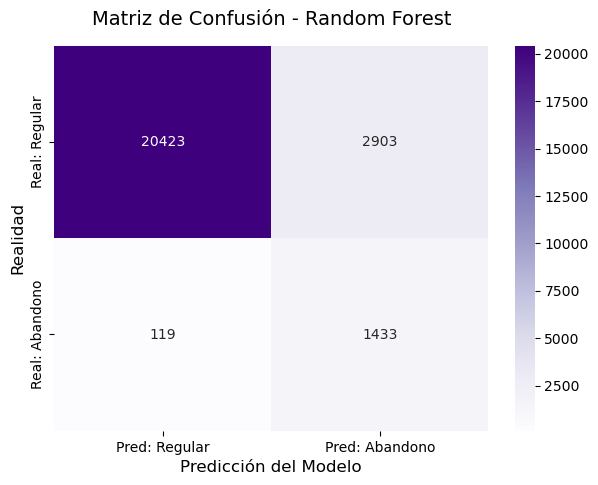

-> Verdaderos Positivos (Alumnos detectados a tiempo): 1433
-> Falsos Negativos (Alumnos que el modelo dejó pasar): 119
-> Falsos Positivos (Alumnos regulares alertados):      2903


In [67]:
# 1. Calculamos la matriz de confusión para el bosque
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 2. La graficamos visualmente mediante Seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Pred: Regular', 'Pred: Abandono'], 
            yticklabels=['Real: Regular', 'Real: Abandono'])

plt.title('Matriz de Confusión - Random Forest', fontsize=14, pad=15)
plt.ylabel('Realidad', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.show()

print(f"-> Verdaderos Positivos (Alumnos detectados a tiempo): {cm_rf[1,1]}")
print(f"-> Falsos Negativos (Alumnos que el modelo dejó pasar): {cm_rf[1,0]}")
print(f"-> Falsos Positivos (Alumnos regulares alertados):      {cm_rf[0,1]}")

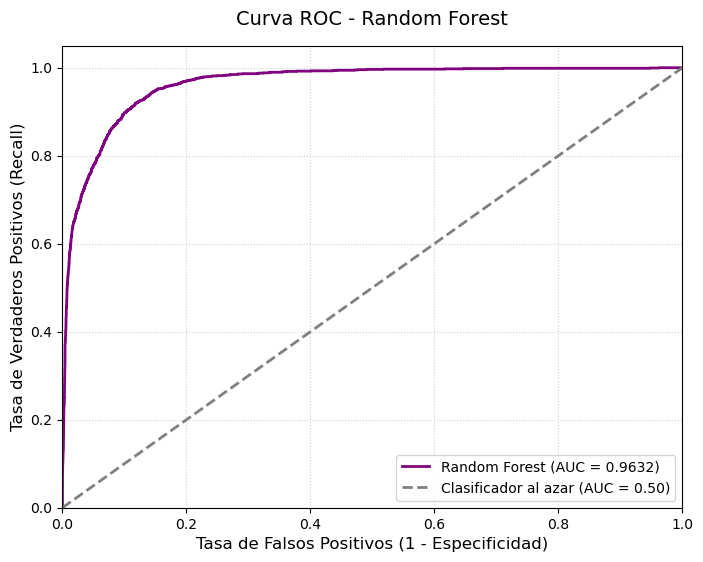

Área Bajo la Curva (AUC) del Bosque: 0.9632


In [68]:
# 1. Obtenemos las probabilidades analíticas de la predicción de la clase 1 (Abandono)
y_probs_rf = modelo_rf.predict_proba(X_test)[:, 1]

# 2. Calculamos los componentes ROC y el AUC del bosque
fpr_rf, tpr_rf, umbrales_rf = roc_curve(y_test, y_probs_rf)
auc_rf = roc_auc_score(y_test, y_probs_rf)

# 3. Graficamos la curva ROC individual
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='purple', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Clasificador al azar (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
plt.title('Curva ROC - Random Forest', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Área Bajo la Curva (AUC) del Bosque: {auc_rf:.4f}")

/tmp/ipykernel_473724/4119545113.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_ordenadas, y=features_ordenadas, palette='viridis')


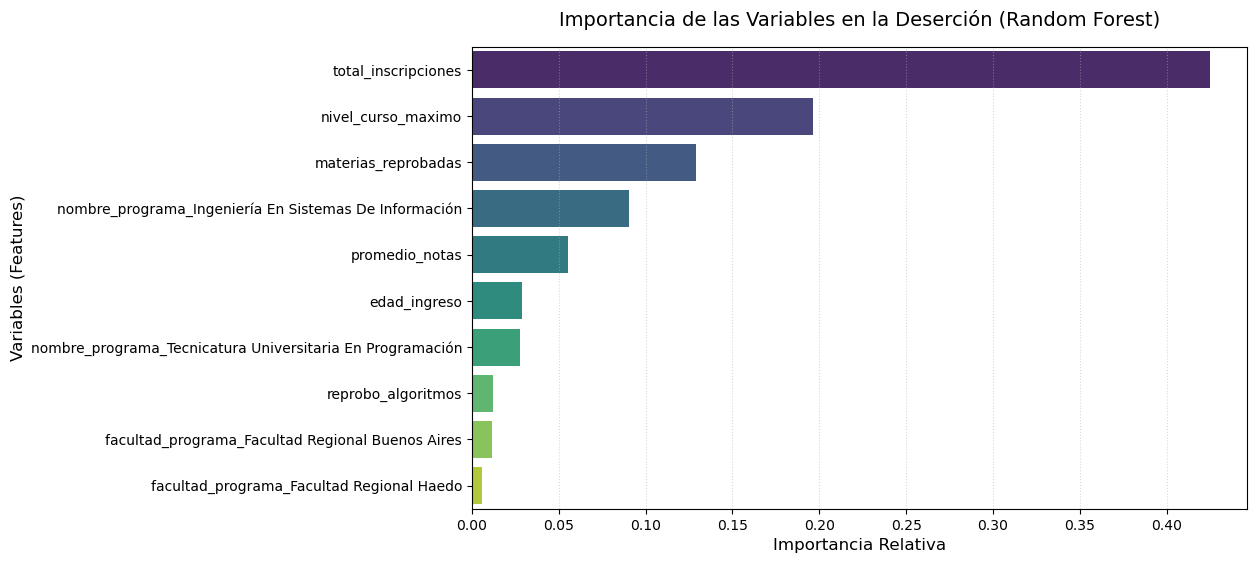

In [69]:
import numpy as np

# 1. Obtenemos las importancias de las variables desde el modelo entrenado
importancias = modelo_rf.feature_importances_
indices = np.argsort(importancias)[::-1]

# Tomamos las 10 variables más influyentes para el gráfico
top_n = min(10, len(X.columns))
features_ordenadas = [X.columns[i] for i in indices[:top_n]]
importancias_ordenadas = importancias[indices[:top_n]]

# 2. Graficamos el impacto en el negocio
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias_ordenadas, y=features_ordenadas, palette='viridis')
plt.title('Importancia de las Variables en la Deserción (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables (Features)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5, axis='x')
plt.show()

---

## FASE 5: EVALUACIÓN DE RESULTADOS ORIENTADA AL NEGOCIO (EVALUATION)
Para definir científicamente cuál es el modelo ganador, consolidamos las curvas ROC de los tres experimentos en un solo gráfico. Evaluamos el rendimiento global de los clasificadores frente a la **Tasa de No Información (NIR = 91.52%)** o *Baseline de la Clase Mayoritaria*, enfocando nuestra brújula analítica en optimizar el **Recall** y el **AUC-ROC**.

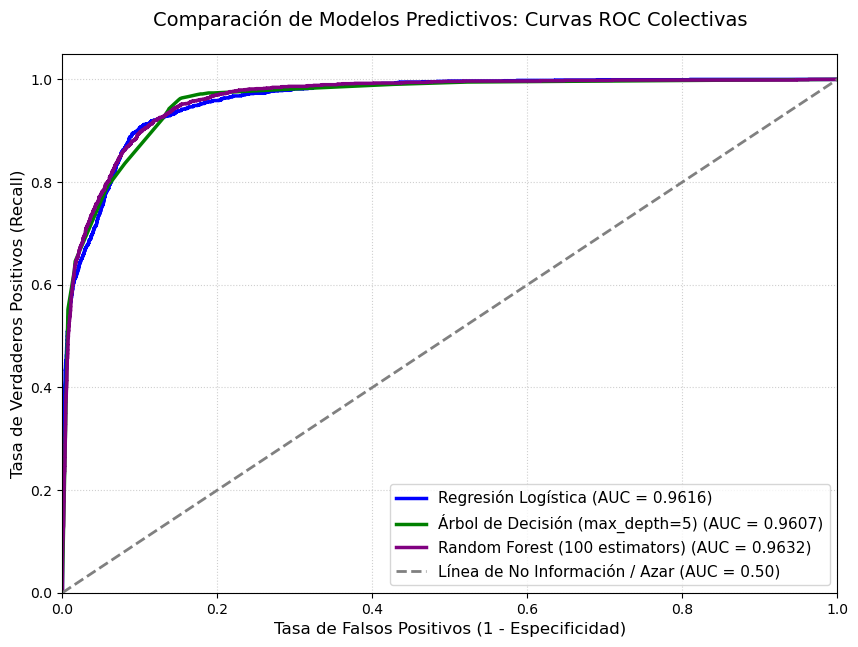

=== TABLA COMPARATIVA DE DESEMPEÑO DE MODELOS ===


,Modelo,Accuracy (Global),Precision,Recall (Métrica Brújula),F1-Score,AUC-ROC (Discriminación)
0,Random Forest,0.878527,0.330489,0.923325,0.486753,0.963188
1,Regresión Logística,0.894083,0.361686,0.912371,0.518017,0.961581
2,Árbol de Decisión,0.856942,0.298777,0.960052,0.455727,0.960722


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN DEL LIENZO DE COMPARACIÓN
plt.figure(figsize=(10, 7))

# Graficamos la curva de la Regresión Logística
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2.5, 
         label=f'Regresión Logística (AUC = {auc_lr:.4f})')

# Graficamos la curva del Árbol de Decisión
plt.plot(fpr_tree, tpr_tree, color='green', lw=2.5, 
         label=f'Árbol de Decisión (max_depth=5) (AUC = {auc_tree:.4f})')

# Graficamos la curva del Random Forest
plt.plot(fpr_rf, tpr_rf, color='purple', lw=2.5, 
         label=f'Random Forest (100 estimators) (AUC = {auc_rf:.4f})')

# Línea base del clasificador aleatorio (baseline)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, 
         label='Línea de No Información / Azar (AUC = 0.50)')

# Ajustes estéticos del gráfico de comparación cruzada
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
plt.title('Comparación de Modelos Predictivos: Curvas ROC Colectivas', fontsize=14, pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 2. CONSOLIDACIÓN ANALÍTICA DE MÉTRICAS EN UN DATAFRAME
data_metricas = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest'],
    'Accuracy (Global)': [accuracy_lr, accuracy_tree, accuracy_rf],
    'Precision': [precision_lr, precision_tree, precision_rf],
    'Recall (Métrica Brújula)': [recall_lr, recall_tree, recall_rf],
    'F1-Score': [f1_lr, f1_tree, f1_rf],
    'AUC-ROC (Discriminación)': [auc_lr, auc_tree, auc_rf]
}

df_comparativo = pd.DataFrame(data_metricas)

# Mostramos la tabla resumen ordenada por AUC
print("=== TABLA COMPARATIVA DE DESEMPEÑO DE MODELOS ===")
display(df_comparativo.sort_values(by='AUC-ROC (Discriminación)', ascending=False).reset_index(drop=True))

---

## FASE 6: AUDITORÍA DE SESGOS E IA RESPONSABLE
Cumpliendo con los lineamientos de ética y limitaciones del TP, desagregamos la métrica brújula (*Recall*) por subgrupos demográficos (género) y geográficos (facultades regionales). Esto nos permite comprobar de forma empírica si el desbalance histórico de la matrícula de Ingeniería en Sistemas introdujo sesgos discriminatorios en las predicciones del algoritmo antes de su paso a producción.

In [72]:
# 1. Creamos un DataFrame temporal con las realidades, las predicciones del modelo ganador
# (asumiendo Random Forest) y las variables demográficas originales de testeo.
df_auditoria = X_test.copy()
df_auditoria['Realidad'] = y_test
df_auditoria['Prediccion'] = y_pred_rf  # Cambialo por el modelo que elijan como ganador

# 2. Desagregamos el RECALL por Género
# Nota: Como usamos drop_first=True en get_dummies, buscamos la columna que haya quedado (ej: 'genero_M')
columna_genero = [c for c in X_test.columns if 'genero' in c][0]

for valor in df_auditoria[columna_genero].unique():
    subgrupo = df_auditoria[df_auditoria[columna_genero] == valor]
    rec = recall_score(subgrupo['Realidad'], subgrupo['Prediccion'])
    etiqueta = "M" if valor == 1 else "F" # Ajustar según su codificación
    print(f"Recall para el subgrupo {etiqueta}: {rec:.4f}")

# 3. Desagregamos el RECALL por las Regionales más masivas
columnas_regionales = [c for c in X_test.columns if 'facultad_programa' in c]
print("\nRecall desagregado por Facultad Regional:")
for col in columnas_regionales:
    # Estudiantes que pertenecen a esa regional específica (valor 1 en el encoding)
    subgrupo = df_auditoria[df_auditoria[col] == 1]
    if len(subgrupo[subgrupo['Realidad'] == 1]) > 0: # Evitamos divisiones por cero si no hay desertores en el subgrupo
        rec = recall_score(subgrupo['Realidad'], subgrupo['Prediccion'])
        print(f" -> {col.replace('facultad_programa_', '')}: {rec:.4f}")

Recall para el subgrupo F: 0.9238
Recall para el subgrupo M: 0.9232

Recall desagregado por Facultad Regional:
 -> Facultad Regional Buenos Aires: 0.9466
 -> Facultad Regional Córdoba: 0.8837
 -> Facultad Regional Haedo: 0.9254
 -> Facultad Regional La Plata: 0.3333
 -> Facultad Regional Mar Del Plata: 0.4000
 -> Facultad Regional Mendoza: 0.6000
 -> Facultad Regional Rosario: 0.9508
 -> Facultad Regional Tucumán: 0.6667
